The supervised models predicted the target distance with ~99% accuracy.

What it really means: This is a classic case of data leakage. The model isn't learning the complex strategy of the movement; it's "cheating" by finding a simple shortcut.

The features included variables like:

* Zmax_index

* FZ_wrist

These are final 3D positions (Z-axis specifically) of hand parts.

But the target distance is also determined by Z-axis values (e.g., ‘far’ targets are placed farther away along the Z-axis).

So the model simply learned:

“If Z is large → target was far;
If Z is small → target was near.”

It never had to analyse the movement itself just where the hand ended up.

Thes notebook performs a clean and methodical analysis for each of the three experiments (prehension, aiming, and illusions). For each one, the code follows the same logical steps:

* Load Data: It starts by loading one of the master datasets.

* Define Leaky Features: It creates a list of string patterns (like Xmax, FY, Zloc) that correspond to the final XYZ position of the hand/fingers—the features that were causing the data leakage.

* Curate Feature Set: The script then intelligently creates a new "curated" list of features by removing any feature whose name contains one of the leaky patterns. This is the crucial step that fixes the leakage problem.

* Prepare for Modeling: It sets up the data (X, y) and defines the subject groups for cross-validation. This ensures that data from the same person doesn't appear in both the training and testing sets, making your accuracy score more reliable.

* Build & Evaluate Pipeline: It uses a scikit-learn Pipeline to first scale the data (StandardScaler) and then classify it with a RandomForestClassifier. It calculates the model's performance using a 5-fold cross-validation, giving a robust measure of its accuracy.

* Generate Feature Importance: Finally, it trains the model one last time on all the data to determine which of the curated features were most important for making its predictions and visualizes the top 20 in a bar plot.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
df_prehension = pd.read_csv("../../data/02_processed/prehension_master_dataset.csv")

leaky_patterns = ['Xmax', 'Ymax', 'Zmax', 'FX', 'FY', 'FZ', 'Xloc', 'Yloc', 'Zloc']

In [3]:
kinematic_features = df_prehension.select_dtypes(include=np.number).columns.tolist()
identifiers = ['subjName', 'trialN']
kinematic_features = [col for col in kinematic_features if col not in identifiers]

curated_features = [
    feat for feat in kinematic_features
    if not any(pattern in feat for pattern in leaky_patterns)
]

print(f"Original number of features: {len(kinematic_features)}")
print(f"Number of curated (non-leaky) features: {len(curated_features)}")
print("\nFirst 10 curated features:", curated_features[:10])


Original number of features: 173
Number of curated (non-leaky) features: 83

First 10 curated features: ['clear.logMAR', 'mono.logMAR', 'bino.logMAR', 'clear.logCS', 'mono.logCS', 'bino.logCS', 'clear.disparity', 'mono.disparity', 'bino.disparity', 'FVel']


In [4]:
# Save this curated feature set for future use
curated_df = df_prehension[curated_features + ['distance', 'subjName']]
curated_df.to_csv("../../data/03_features/prehension_curated_features.csv", index=False)

# Re Run the Supervised Model on Curated Data

In [5]:
# Prepare data for the model
X_curated = df_prehension[curated_features]
y_supervised = df_prehension['distance']
groups = df_prehension['subjName']

# Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y_supervised)


In [6]:
# Define the pipeline
pipeline = Pipeline([
    ('scalar', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# Use GroupKFold for subject-aware splitting
group_kfold = GroupKFold(n_splits=5) 

print("\nPerforming 5-fold subject-aware cross-validation on CURATED features...")
cv_scores = cross_val_score(pipeline, X_curated, y_encoded, cv=group_kfold, groups=groups)

print(f"\nCross-validation accuracy scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")



Performing 5-fold subject-aware cross-validation on CURATED features...

Cross-validation accuracy scores: [0.97682709 0.99295775 0.99119718 0.98765432 0.99644128]
Mean CV Accuracy: 0.9890 (+/- 0.0067)


# Analyse the new features

In [7]:

pipeline.fit(X_curated, y_encoded)
rf_model = pipeline.named_steps['classifier']
importances = rf_model.feature_importances_

# Create a DataFrame for visualisation
feature_importance_df = pd.DataFrame({
    'feature': curated_features,
    'importance': importances
}).sort_values('importance', ascending=False)


C:\Users\bharg\AppData\Local\Temp\ipykernel_18628\2827952322.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='rocket')


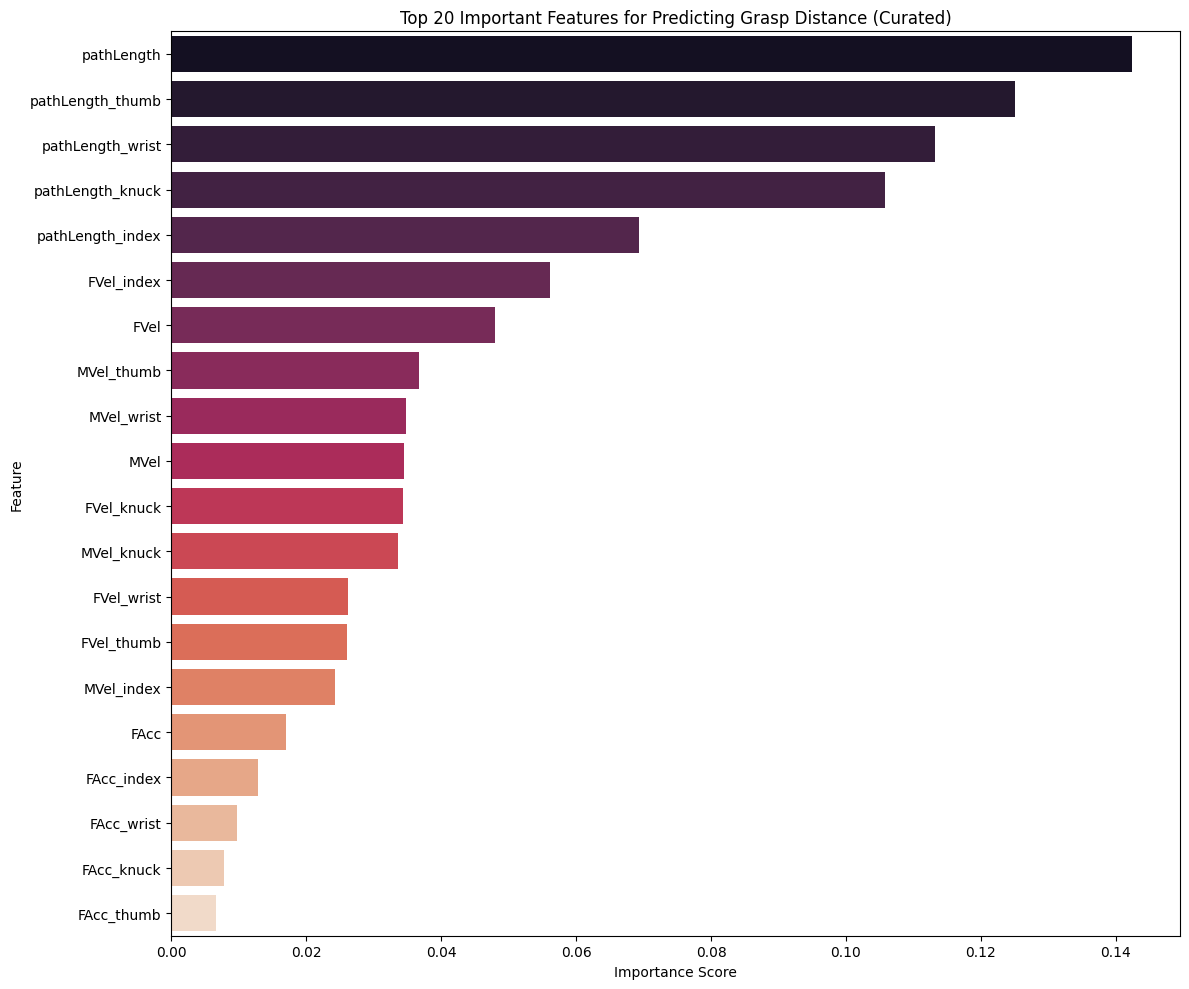


Top 10 most important features (CURATED):
             feature  importance
17        pathLength    0.142392
57  pathLength_thumb    0.125115
58  pathLength_wrist    0.113244
56  pathLength_knuck    0.105747
55  pathLength_index    0.069381
39        FVel_index    0.056060
9               FVel    0.047956
53        MVel_thumb    0.036722
54        MVel_wrist    0.034787
11              MVel    0.034459


In [8]:
# Plot the new importances
plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='rocket')
plt.title('Top 20 Important Features for Predicting Grasp Distance (Curated)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig("../../results/figures/prehension_curated_feature_importance.png")
plt.show()

print("\nTop 10 most important features (CURATED):")
print(feature_importance_df.head(10))

# path length and fval

We successfully moved the model from a trivial answer (final position) to a physical necessity. To reach a target that is farther away, the hand must travel a longer distance (pathLength). This is a fundamental physical constraint of the task. The model has correctly learned that path length is the most powerful predictor of distance. The importance of velocity features also makes sense, as movements to different distances require different speed profiles. This is a valid and strong finding, confirming that the primary kinematic difference between grasping near and far objects is, unsurprisingly, the length and speed of the movement.

## Running the same model after removing the pathlength

In [3]:
df_prehension = pd.read_csv("../../data/02_processed/prehension_master_dataset.csv")

leaky_patterns = ['Xmax', 'Ymax', 'Zmax', 'FX', 'FY', 'FZ', 'Xloc', 'Yloc', 'Zloc', 'pathLength', 'pathLength_index', 'pathLength_thumb', 'pathLength_wrist', 'pathLength_knuck', 'FVel_index', 'FVel']


In [4]:
kinematic_features = df_prehension.select_dtypes(include=np.number).columns.tolist()
identifiers = ['subjName', 'trialN']
kinematic_features = [col for col in kinematic_features if col not in identifiers]

curated_features = [
    feat for feat in kinematic_features
    if not any(pattern in feat for pattern in leaky_patterns)
]

print(f"Original number of features: {len(kinematic_features)}")
print(f"Number of curated (non-leaky) features: {len(curated_features)}")
print("\nFirst 10 curated features:", curated_features[:10])


Original number of features: 173
Number of curated (non-leaky) features: 73

First 10 curated features: ['clear.logMAR', 'mono.logMAR', 'bino.logMAR', 'clear.logCS', 'mono.logCS', 'bino.logCS', 'clear.disparity', 'mono.disparity', 'bino.disparity', 'FAcc']


In [5]:
# Prepare data for the model
X_curated = df_prehension[curated_features]
y_supervised = df_prehension['distance']
groups = df_prehension['subjName']

# Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y_supervised)

In [6]:
# Define the pipeline
pipeline = Pipeline([
    ('scalar', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# Use GroupKFold for subject-aware splitting
group_kfold = GroupKFold(n_splits=5) 

print("\nPerforming 5-fold subject-aware cross-validation on CURATED features...")
cv_scores = cross_val_score(pipeline, X_curated, y_encoded, cv=group_kfold, groups=groups)

print(f"\nCross-validation accuracy scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")


Performing 5-fold subject-aware cross-validation on CURATED features...

Cross-validation accuracy scores: [0.97326203 0.90492958 0.95950704 0.9664903  0.98754448]
Mean CV Accuracy: 0.9583 (+/- 0.0283)


In [7]:

pipeline.fit(X_curated, y_encoded)
rf_model = pipeline.named_steps['classifier']
importances = rf_model.feature_importances_

# Create a DataFrame for visualisation
feature_importance_df = pd.DataFrame({
    'feature': curated_features,
    'importance': importances
}).sort_values('importance', ascending=False)

C:\Users\bharg\AppData\Local\Temp\ipykernel_16996\692046999.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='rocket')


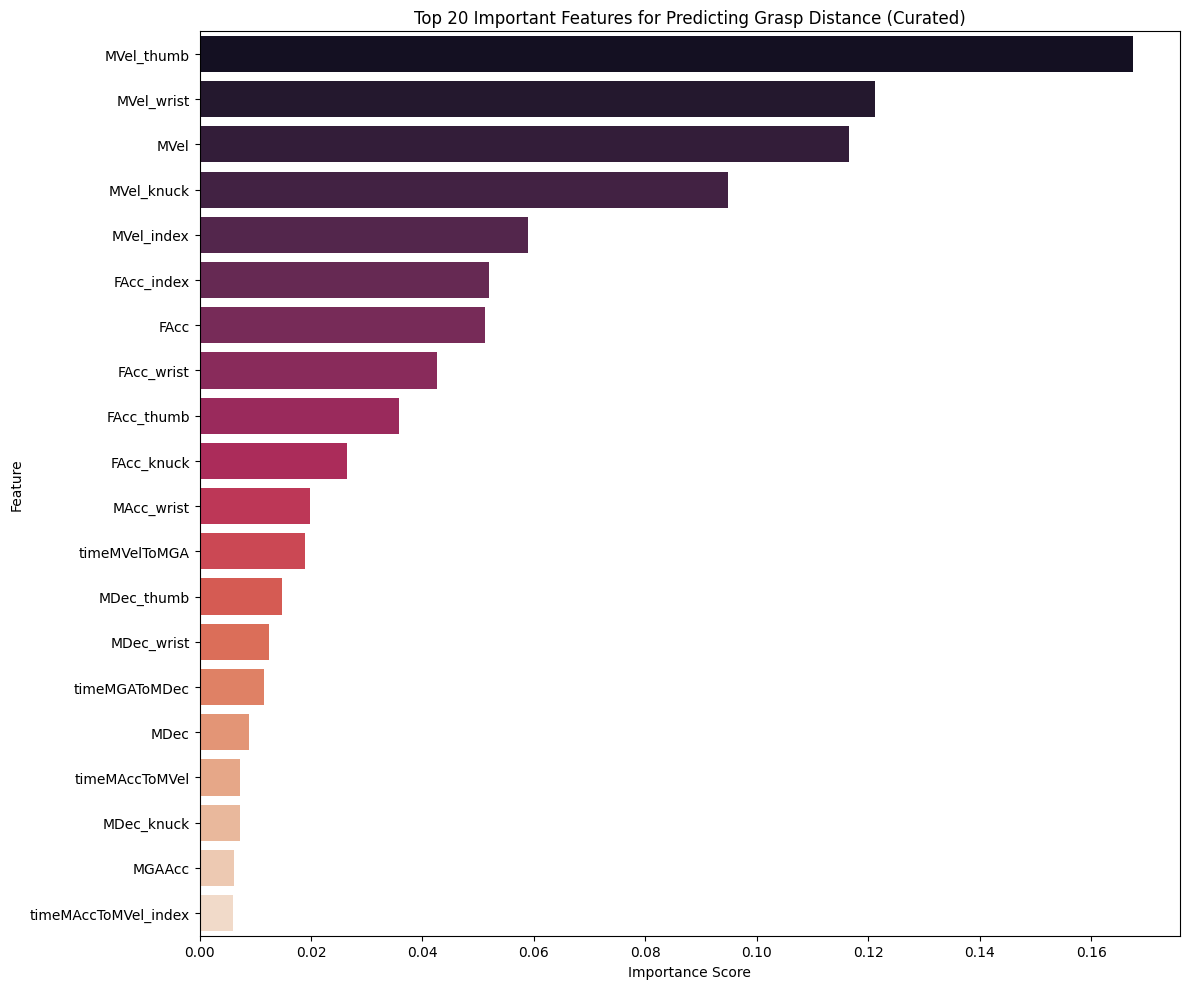


Top 10 most important features (CURATED):
       feature  importance
47  MVel_thumb    0.167573
48  MVel_wrist    0.121236
10        MVel    0.116604
46  MVel_knuck    0.094870
45  MVel_index    0.058972
33  FAcc_index    0.051972
9         FAcc    0.051152
36  FAcc_wrist    0.042562
35  FAcc_thumb    0.035742
34  FAcc_knuck    0.026552


In [8]:
# Plot the new importances
plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='rocket')
plt.title('Top 20 Important Features for Predicting Grasp Distance (Curated)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
# plt.savefig("../../results/figures/prehension_curated_feature_importance.png")
plt.show()

print("\nTop 10 most important features (CURATED):")
print(feature_importance_df.head(10))

# Refining Aiming Dataset

In [9]:
df_aiming = pd.read_csv("../../data/02_processed/aiming_master_dataset.csv")

In [10]:
# Define leaky features
leaky_patterns = ['Xmax', 'Ymax', 'Zmax', 'FX', 'FY', 'FZ', 'Xloc', 'Yloc', 'Zloc']
kinematic_features_aiming = df_aiming.select_dtypes(include=np.number).columns.tolist()
identifiers = ['subjName', 'trialN']
kinematic_features_aiming = [col for col in kinematic_features_aiming if col not in identifiers]

In [11]:
# Create the curated feature list
curated_features_aiming = [
    feat for feat in kinematic_features_aiming
    if not any(pattern in feat for pattern in leaky_patterns)
]

print(f"Aiming - Original number of features: {len(kinematic_features_aiming)}")
print(f"Aiming - Number of curated features: {len(curated_features_aiming)}")

# Prepare data for the model
X_curated_aiming = df_aiming[curated_features_aiming]
y_supervised_aiming = df_aiming['distance']
groups_aiming = df_aiming['subjName']

# Encode the target variable
le_aiming = LabelEncoder()
y_encoded_aiming = le_aiming.fit_transform(y_supervised_aiming)


Aiming - Original number of features: 205
Aiming - Number of curated features: 97


In [12]:
# Define the pipeline
pipeline_aiming = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])


In [13]:
# Cross-validation
group_kfold = GroupKFold(n_splits=5) 
cv_scores_aiming = cross_val_score(pipeline_aiming, X_curated_aiming, y_encoded_aiming, cv=group_kfold, groups=groups_aiming)

print(f"\nAiming - Curated CV Accuracy Scores: {cv_scores_aiming}")
print(f"Aiming - Mean Curated CV Accuracy: {np.mean(cv_scores_aiming):.4f} (+/- {np.std(cv_scores_aiming):.4f})")



Aiming - Curated CV Accuracy Scores: [1.         0.99274047 0.98312236 0.97652582 0.99765258]
Aiming - Mean Curated CV Accuracy: 0.9900 (+/- 0.0089)


C:\Users\bharg\AppData\Local\Temp\ipykernel_18628\1769498608.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df_aiming.head(20), palette='rocket')


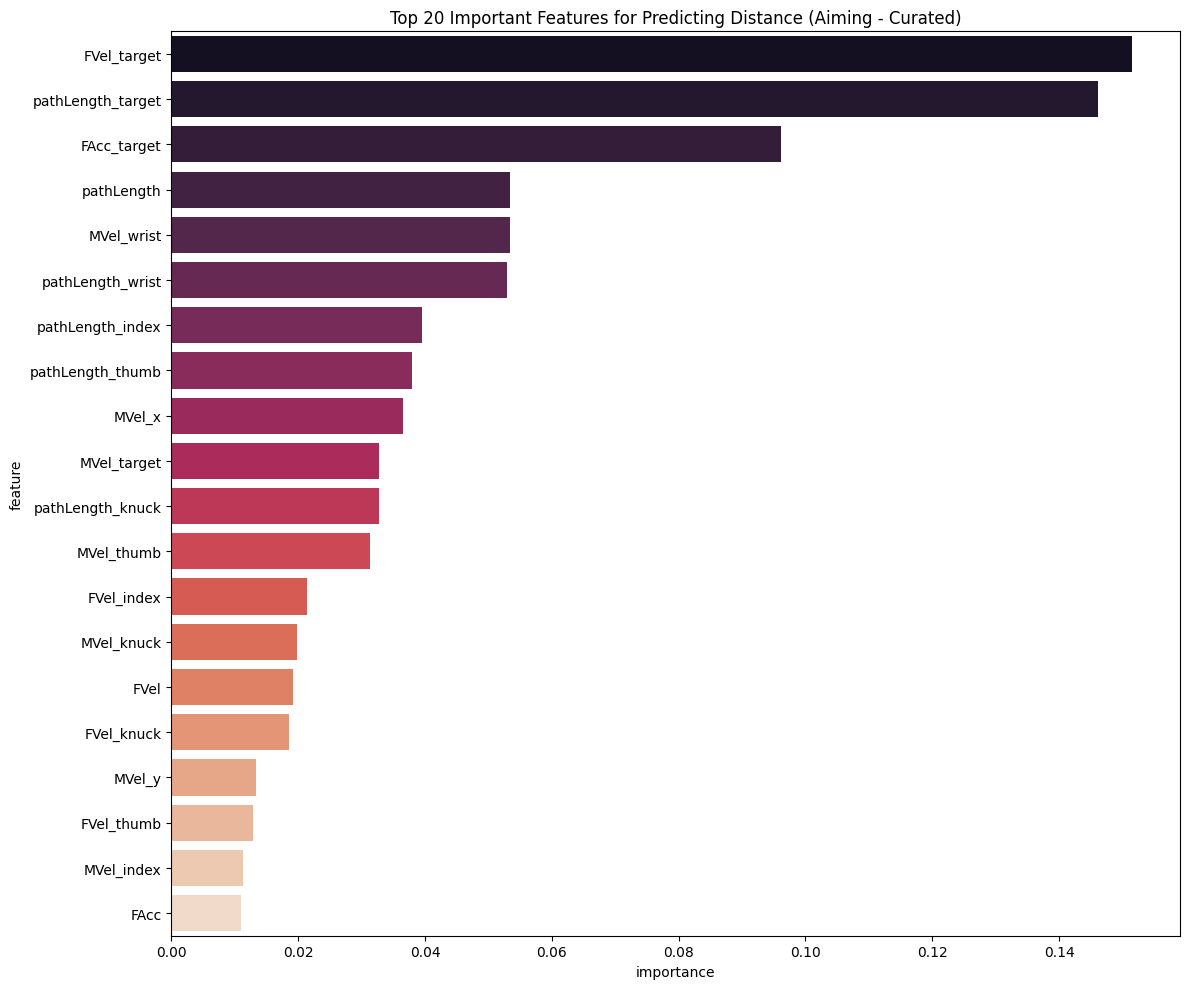


Top 10 most important features (CURATED):
              feature  importance
44        FVel_target    0.151481
64  pathLength_target    0.146111
39        FAcc_target    0.096100
22         pathLength    0.053387
61         MVel_wrist    0.053365
66   pathLength_wrist    0.052901
62   pathLength_index    0.039570
65   pathLength_thumb    0.037904
10             MVel_x    0.036490
59        MVel_target    0.032783


In [15]:
# Feature Importance
pipeline_aiming.fit(X_curated_aiming, y_encoded_aiming)
importances_aiming = pipeline_aiming.named_steps['classifier'].feature_importances_
feature_importance_df_aiming = pd.DataFrame({
    'feature': curated_features_aiming,
    'importance': importances_aiming
}).sort_values('importance', ascending=False)

# Plot
plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importance_df_aiming.head(20), palette='rocket')
plt.title('Top 20 Important Features for Predicting Distance (Aiming - Curated)')
plt.tight_layout()
plt.savefig("../../results/figures/aiming_curated_feature_importance.png")
plt.show()
print("\nTop 10 most important features (CURATED):")
print(feature_importance_df_aiming.head(10))

Just like with grasping, the model has locked onto the most direct physical consequences of the experimental setup. The length of the movement (pathLength_target) and the velocity/acceleration profiles (FVel_target, FAcc_target) are the most dominant signals that differentiate aiming distances. This model is no longer cheating, it's correctly identifying the true kinematic markers that are intrinsically linked to the target's distance.

# Refine Visual Illusions

In [16]:
df_illusions = pd.read_csv("../../data/02_processed/visual_illusions_master_dataset.csv")


In [17]:
kinematic_features_illusions = df_illusions.select_dtypes(include=np.number).columns.tolist()
kinematic_features_illusions = [col for col in kinematic_features_illusions if col not in identifiers and col not in ['targetSize']]

curated_features_illusions = [
    feat for feat in kinematic_features_illusions
    if not any(pattern in feat for pattern in leaky_patterns)
]

print(f"Illusions - Original number of features: {len(kinematic_features_illusions)}")
print(f"Illusions - Number of curated features: {len(curated_features_illusions)}")


Illusions - Original number of features: 164
Illusions - Number of curated features: 74


In [18]:
# Prepare data
X_curated_illusions = df_illusions[curated_features_illusions]
y_supervised_illusions = df_illusions['illusion']
groups_illusions = df_illusions['subjName']

# Encode
le_illusions = LabelEncoder()
y_encoded_illusions = le_illusions.fit_transform(y_supervised_illusions)

# Pipeline
pipeline_illusions = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

In [19]:
# CV
cv_scores_illusions = cross_val_score(pipeline_illusions, X_curated_illusions, y_encoded_illusions, cv=group_kfold, groups=groups_illusions)

print(f"\nIllusions - Curated CV Accuracy Scores: {cv_scores_illusions}")
print(f"Illusions - Mean Curated CV Accuracy: {np.mean(cv_scores_illusions):.4f} (+/- {np.std(cv_scores_illusions):.4f})")


Illusions - Curated CV Accuracy Scores: [0.77160494 0.64814815 0.70897833 0.7571885  0.65740741]
Illusions - Mean Curated CV Accuracy: 0.7087 (+/- 0.0502)


C:\Users\bharg\AppData\Local\Temp\ipykernel_18628\2650717842.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df_illusions.head(20), palette='rocket')


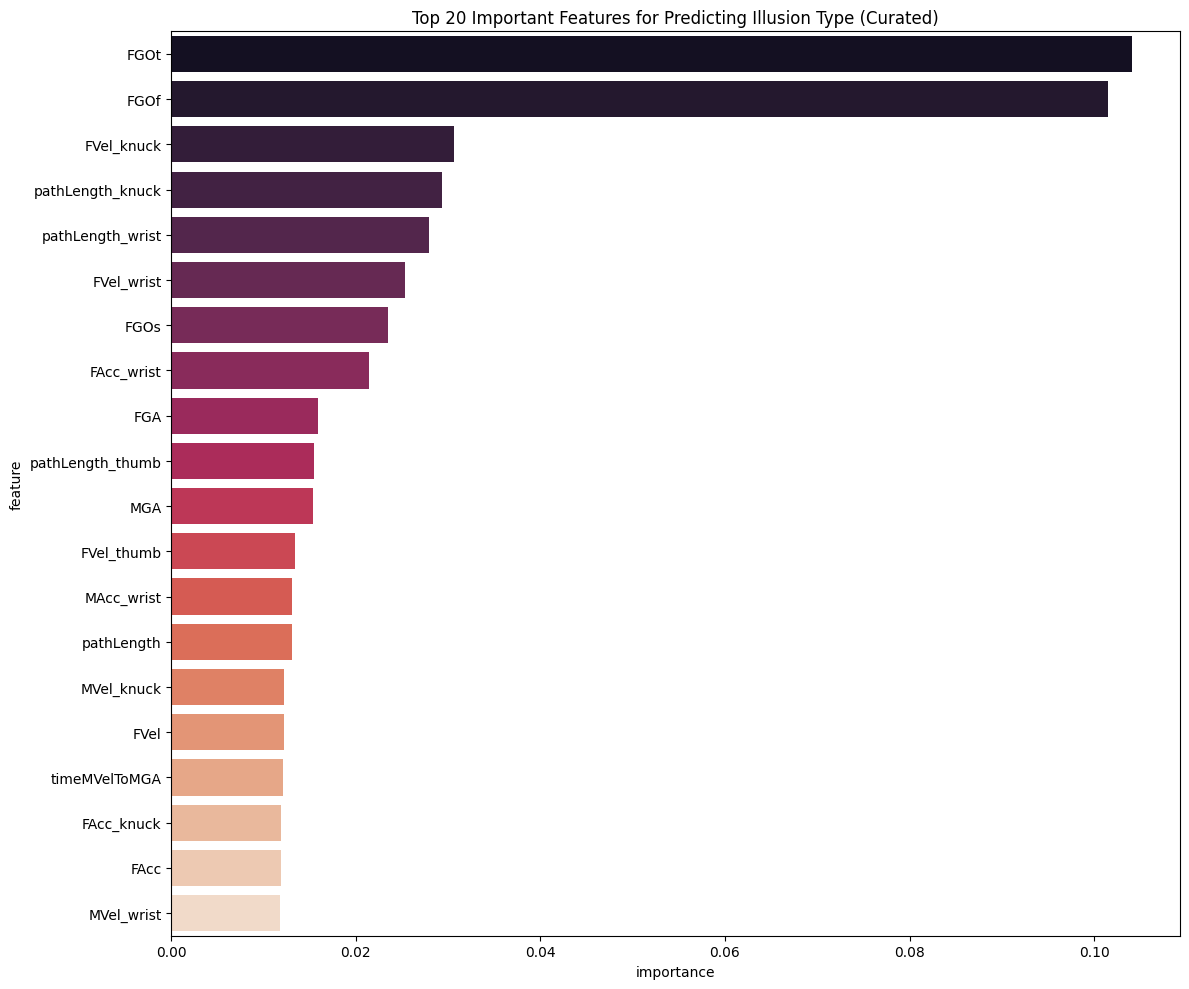


Top 10 most important features (CURATED):
             feature  importance
21              FGOt    0.104104
20              FGOf    0.101525
31        FVel_knuck    0.030670
47  pathLength_knuck    0.029332
49  pathLength_wrist    0.027969
33        FVel_wrist    0.025381
22              FGOs    0.023433
29        FAcc_wrist    0.021379
12               FGA    0.015850
48  pathLength_thumb    0.015453


In [21]:
# Feature Importance
pipeline_illusions.fit(X_curated_illusions, y_encoded_illusions)
importances_illusions = pipeline_illusions.named_steps['classifier'].feature_importances_
feature_importance_df_illusions = pd.DataFrame({
    'feature': curated_features_illusions,
    'importance': importances_illusions
}).sort_values('importance', ascending=False)

# Plot
plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importance_df_illusions.head(20), palette='rocket')
plt.title('Top 20 Important Features for Predicting Illusion Type (Curated)')
plt.tight_layout()
plt.savefig("../../results/figures/illusions_curated_feature_importance.png")
plt.show()

print("\nTop 10 most important features (CURATED):")
print(feature_importance_df_illusions.head(10))

This strongly supports the hypothesis. Even after a rigorous feature curation process, the model insists that the final orientation of the hand (FGOt, FGOf) is the most important clue for telling the two illusion types apart. This provides powerful evidence that the illusion's effect on motor control is not on the gross transport of the arm, but rather on the subtle, final adjustments of the hand as it shapes itself to the perceived object. The presence of MGA (Maximum Grip Aperture) further down the list, a classic metric in grasping studies, adds even more credibility to this finding.

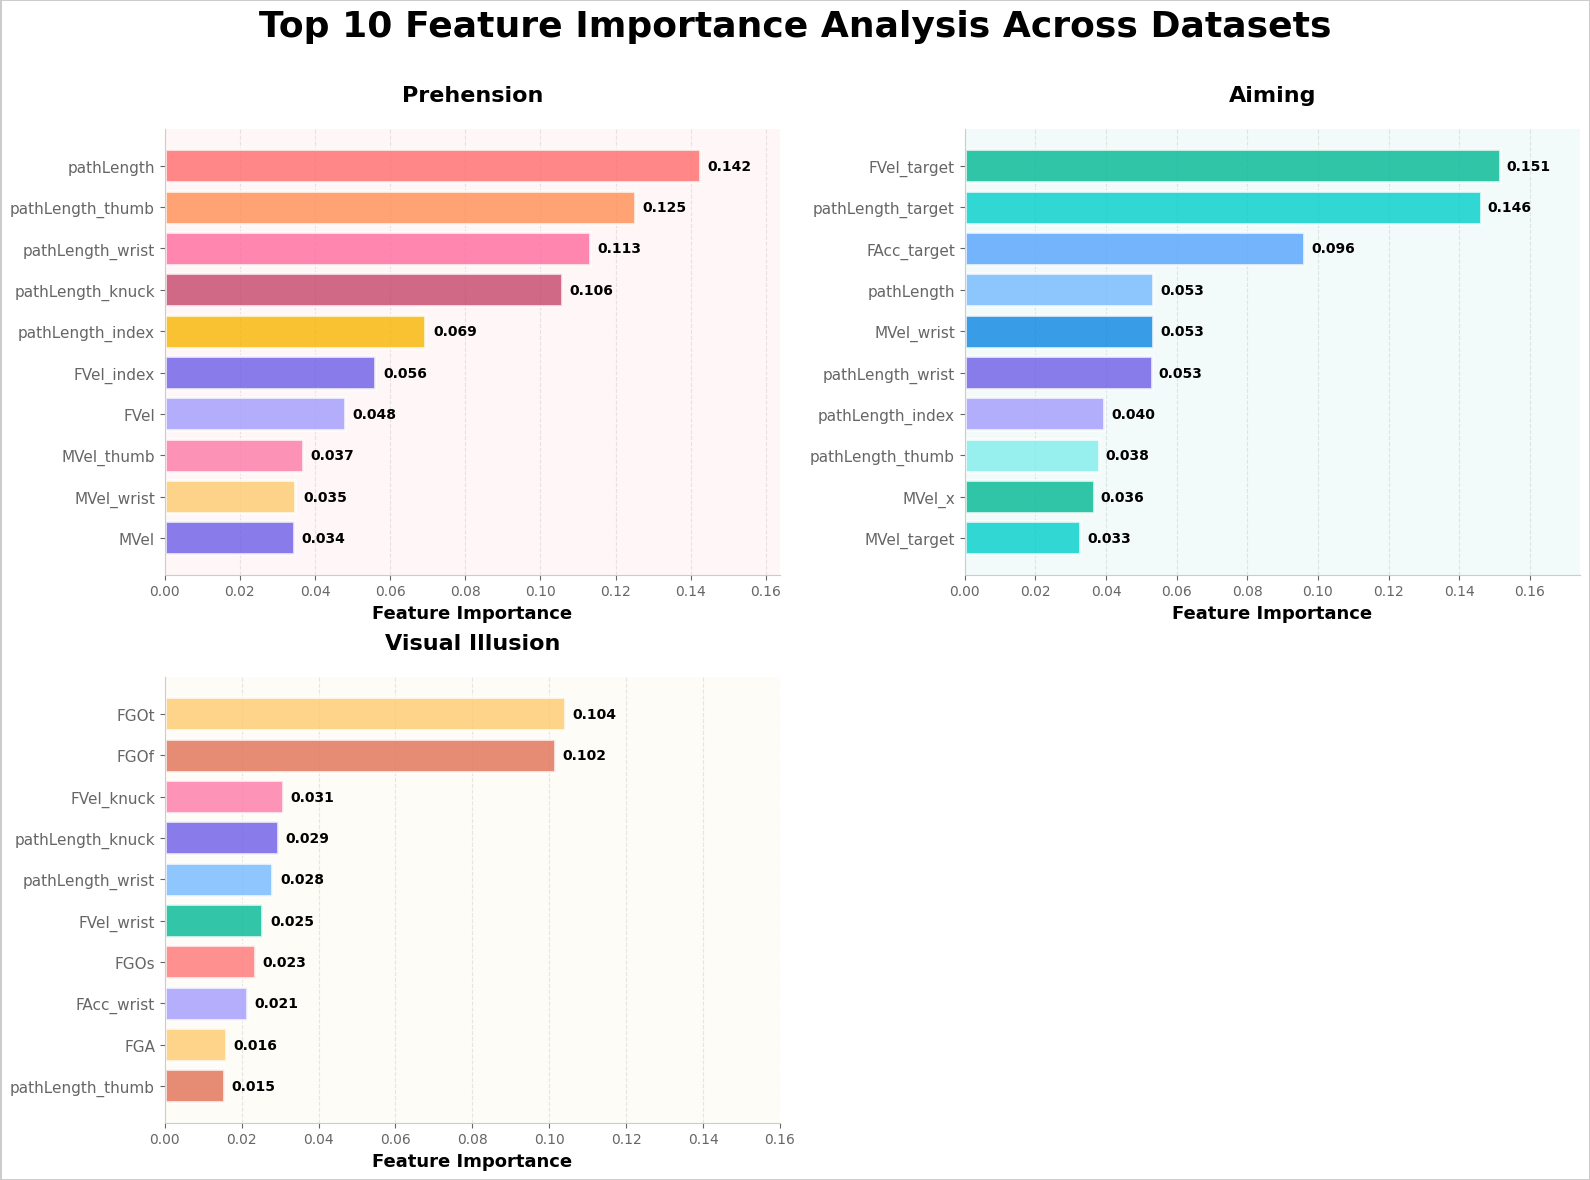

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
import seaborn as sns

# Set up the style
plt.style.use('default')
sns.set_palette("husl")

# Data for the three datasets
prehension_data = {
    'feature': ['pathLength', 'pathLength_thumb', 'pathLength_wrist', 'pathLength_knuck', 
                'pathLength_index', 'FVel_index', 'FVel', 'MVel_thumb', 'MVel_wrist', 'MVel'],
    'importance': [0.142392, 0.125115, 0.113244, 0.105747, 0.069381, 
                   0.056060, 0.047956, 0.036722, 0.034787, 0.034459]
}

aiming_data = {
    'feature': ['FVel_target', 'pathLength_target', 'FAcc_target', 'pathLength', 'MVel_wrist',
                'pathLength_wrist', 'pathLength_index', 'pathLength_thumb', 'MVel_x', 'MVel_target'],
    'importance': [0.151481, 0.146111, 0.096100, 0.053387, 0.053365,
                   0.052901, 0.039570, 0.037904, 0.036490, 0.032783]
}

visual_illusion_data = {
    'feature': ['FGOt', 'FGOf', 'FVel_knuck', 'pathLength_knuck', 'pathLength_wrist',
                'FVel_wrist', 'FGOs', 'FAcc_wrist', 'FGA', 'pathLength_thumb'],
    'importance': [0.104104, 0.101525, 0.030670, 0.029332, 0.027969,
                   0.025381, 0.023433, 0.021379, 0.015850, 0.015453]
}

# Create DataFrames
df_prehension = pd.DataFrame(prehension_data)
df_aiming = pd.DataFrame(aiming_data)
df_visual = pd.DataFrame(visual_illusion_data)

# Create the figure with subplots in 2 rows
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Top 10 Feature Importance Analysis Across Datasets', 
             fontsize=26, fontweight='bold', y=0.98)

# Flatten axes for easier access and hide the empty subplot
axes = axes.flatten()
axes[3].set_visible(False)  # Hide the 4th subplot since we only have 3 datasets

# Color schemes for each dataset
colors = {
    'prehension': ['#FF6B6B', '#FF8E53', '#FF6B9D', '#C44569', '#F8B500', 
                   '#6C5CE7', '#A29BFE', '#FD79A8', '#FDCB6E', '#6C5CE7'],
    'aiming': ['#00B894', '#00CEC9', '#55A3FF', '#74B9FF', '#0984E3',
               '#6C5CE7', '#A29BFE', '#81ECEC', '#00B894', '#00CEC9'],
    'visual': ['#FDCB6E', '#E17055', '#FD79A8', '#6C5CE7', '#74B9FF',
               '#00B894', '#FF7675', '#A29BFE', '#FDCB6E', '#E17055']
}

datasets = [
    (df_prehension, 'Prehension', 'prehension', axes[0]),
    (df_aiming, 'Aiming', 'aiming', axes[1]),
    (df_visual, 'Visual Illusion', 'visual', axes[2])
]

# Plot each dataset
for df, title, color_key, ax in datasets:
    # Create horizontal bar plot
    bars = ax.barh(range(len(df)), df['importance'], 
                   color=colors[color_key], alpha=0.8, edgecolor='white', linewidth=2)
    
    # Customize the plot
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df['feature'], fontsize=11, fontweight='medium')
    ax.set_xlabel('Feature Importance', fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width + 0.002, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', ha='left', va='center', 
                fontweight='bold', fontsize=10)
    
    # Styling
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.tick_params(colors='#666666')
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Invert y-axis to show highest importance at top
    ax.invert_yaxis()
    
    # Set consistent x-axis limits for better comparison
    ax.set_xlim(0, max(df['importance'].max() * 1.15, 0.16))

# Add subtle background colors to distinguish datasets
for i, (_, title, color_key, ax) in enumerate(datasets):
    rect = Rectangle((0, 0), 1, 1, transform=ax.transAxes, 
                     facecolor=colors[color_key][0], alpha=0.05, zorder=0)
    ax.add_patch(rect)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.88, wspace=0.3)

# Add a subtle border around the entire figure
fig.patch.set_edgecolor('#CCCCCC')
fig.patch.set_linewidth(2)

# Display the plot
plt.show()

# Optional: Save the plot
# plt.savefig('feature_importance_analysis.png', dpi=300, bbox_inches='tight', 
#             facecolor='white', edgecolor='#CCCCCC')